# Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, adjusted_rand_score

# Load Iris Dataset

In [4]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("Dataset Shape:", X.shape)
print("Features:", feature_names)
print("Classes:", target_names)

Dataset Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


In [5]:
df = pd.DataFrame(
    X,
    columns=feature_names
)

df["True_Label"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),True_Label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   True_Label         150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB
None

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
True_Label           0
dtype: int64

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),True_Label
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


C:\Users\Lenovo\Downloads\PR\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Lenovo\Downloads\PR\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Lenovo\Downloads\PR\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Lenovo\Downloads\PR\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN 

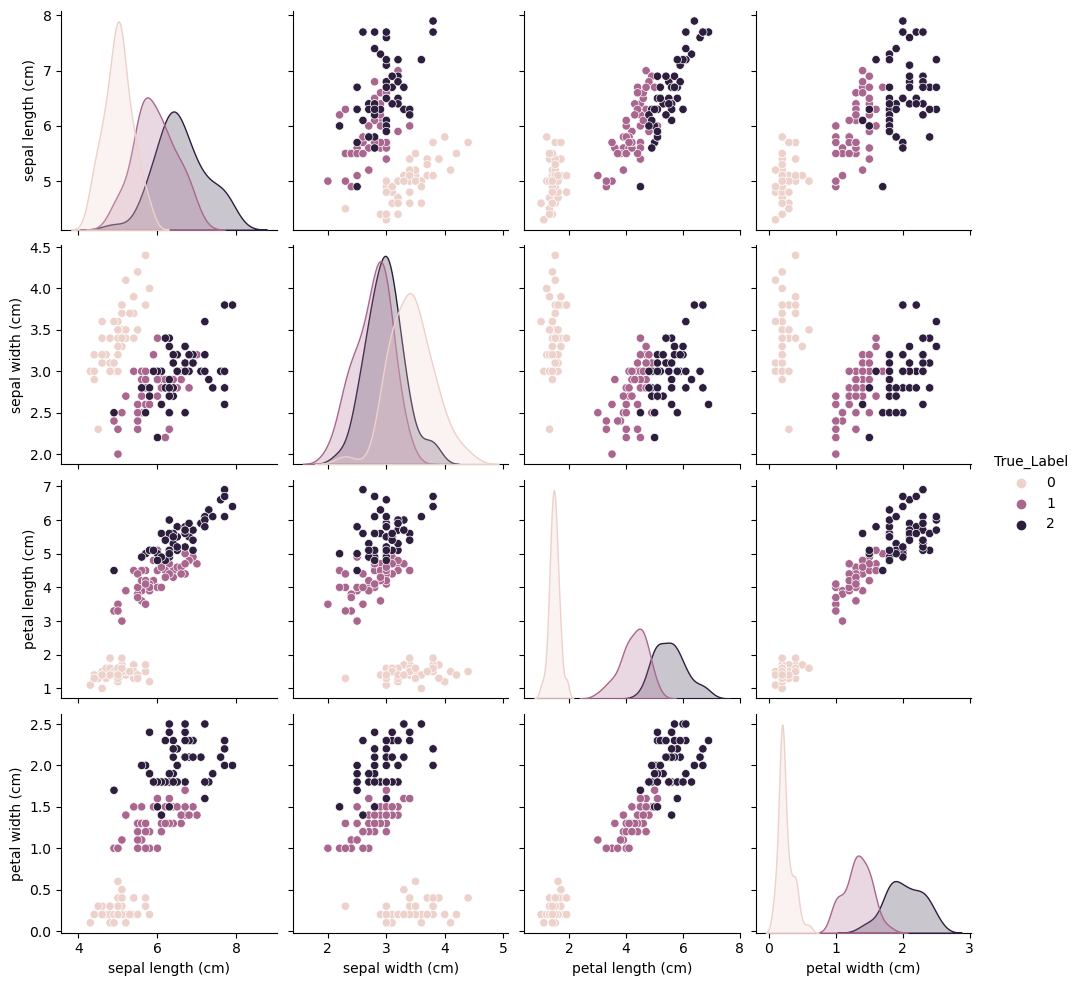

In [9]:
sns.pairplot(
    df,
    hue="True_Label"
)

plt.show()

# Standardize the Data

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Data:")
print(X_scaled[:5])

Scaled Data:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


# Apply K-Means Clustering

In [13]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

C:\Users\Lenovo\Downloads\PR\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3, n_init=10, random_state=42)

In [14]:
predicted_clusters = kmeans.labels_

print("Predicted Clusters:")
print(predicted_clusters)

Predicted Clusters:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 2 2 0 2 2 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2
 2 0 0 0 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 0 0 0 0 0 0 2 2 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


# Add Cluster Results to Dataset

In [15]:
df["Predicted_Cluster"] = predicted_clusters

df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),True_Label,Predicted_Cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1
5,5.4,3.9,1.7,0.4,0,1
6,4.6,3.4,1.4,0.3,0,1
7,5.0,3.4,1.5,0.2,0,1
8,4.4,2.9,1.4,0.2,0,1
9,4.9,3.1,1.5,0.1,0,1


# Visualize K-Means Clusters

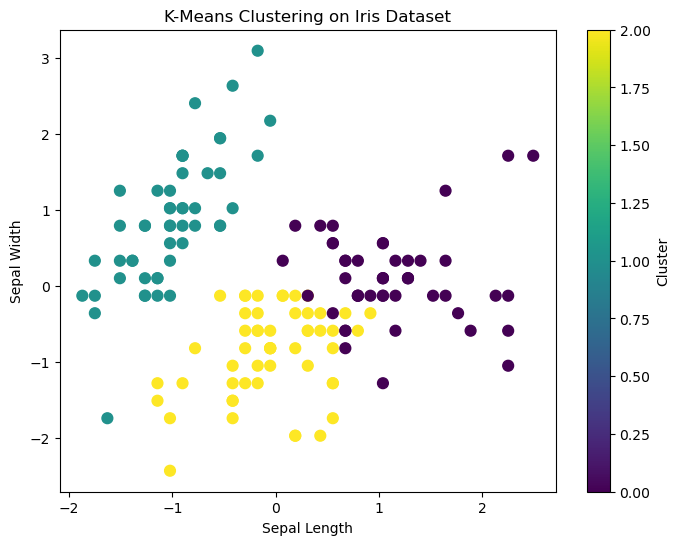

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=predicted_clusters,
    cmap="viridis",
    s=60
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")

plt.title("K-Means Clustering on Iris Dataset")

plt.colorbar(label="Cluster")

plt.show()

# Apply PCA

In [17]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X_scaled)

print("Original Shape:", X_scaled.shape)
print("PCA Shape:", X_pca.shape)

Original Shape: (150, 4)
PCA Shape: (150, 2)


In [18]:
print(
    "Explained Variance Ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total Explained Variance:",
    pca.explained_variance_ratio_.sum()
)

Explained Variance Ratio: [0.72962445 0.22850762]
Total Explained Variance: 0.9581320720000165


# Visualize K-Means Clusters using PCA

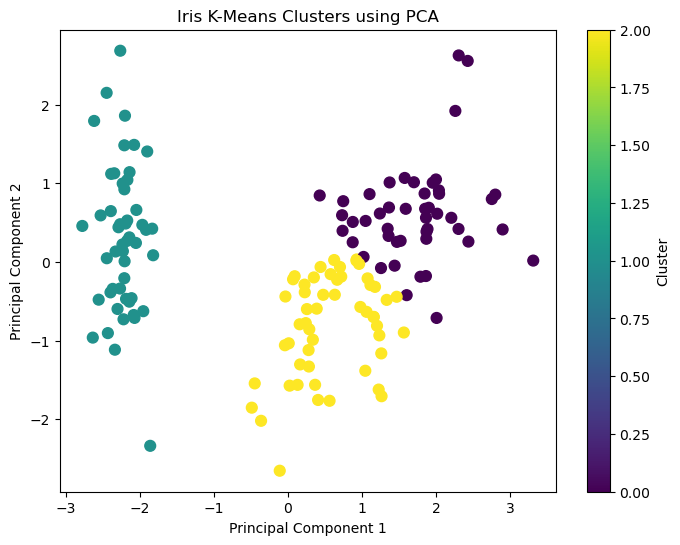

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=predicted_clusters,
    cmap="viridis",
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("Iris K-Means Clusters using PCA")

plt.colorbar(label="Cluster")

plt.show()

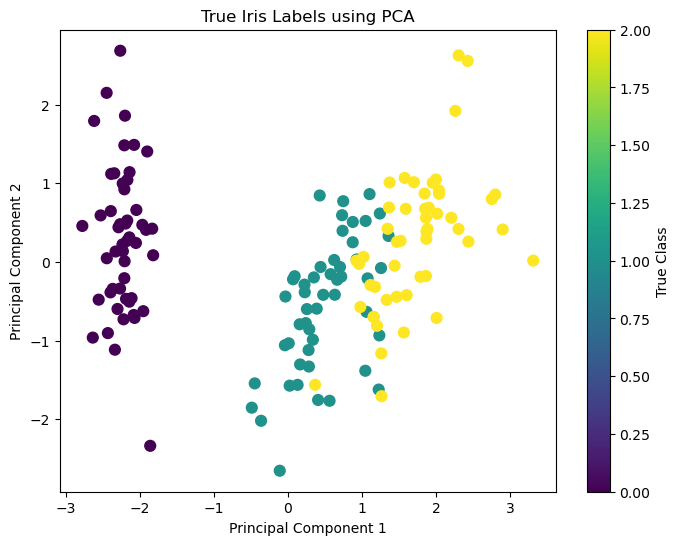

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis",
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("True Iris Labels using PCA")

plt.colorbar(label="True Class")

plt.show()

# Compare Predicted Clusters vs True Labels

In [21]:
ari_score = adjusted_rand_score(
    y,
    predicted_clusters
)

print("Adjusted Rand Index (ARI):", ari_score)

Adjusted Rand Index (ARI): 0.6201351808870379


In [22]:
cm = confusion_matrix(
    y,
    predicted_clusters
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 0 50  0]
 [11  0 39]
 [36  0 14]]


In [23]:
comparison = pd.DataFrame({
    "True_Label": y,
    "Predicted_Cluster": predicted_clusters
})

comparison.head(20)

,True_Label,Predicted_Cluster
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1
5,0,1
6,0,1
7,0,1
8,0,1
9,0,1


In [24]:
cluster_counts = pd.Series(
    predicted_clusters
).value_counts().sort_index()

print("Number of samples in each cluster:")
print(cluster_counts)

Number of samples in each cluster:
0    47
1    50
2    53
Name: count, dtype: int64


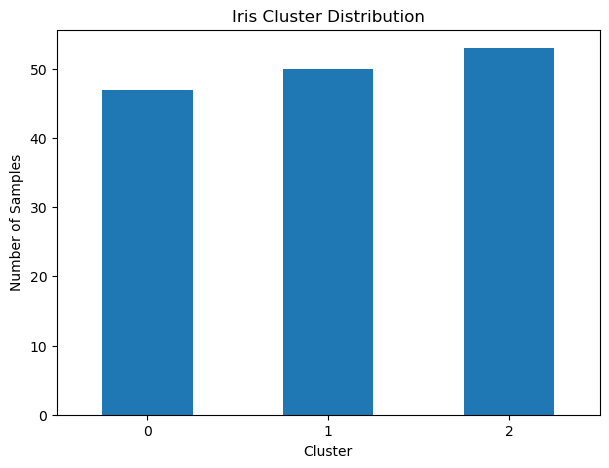

In [25]:
plt.figure(figsize=(7, 5))

cluster_counts.plot(
    kind="bar"
)

plt.xlabel("Cluster")
plt.ylabel("Number of Samples")

plt.title("Iris Cluster Distribution")

plt.xticks(rotation=0)

plt.show()

# Find K Using Elbow Method

In [26]:
inertia = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

C:\Users\Lenovo\Downloads\PR\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\Downloads\PR\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\Downloads\PR\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\Downloads\PR\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memor

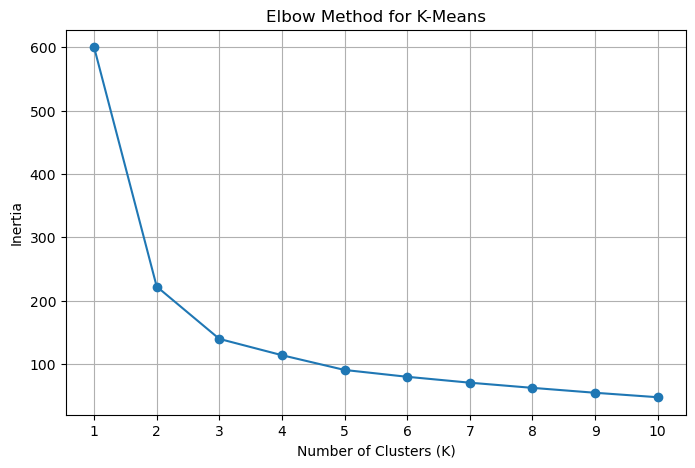

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.title("Elbow Method for K-Means")

plt.xticks(range(1, 11))
plt.grid(True)

plt.show()

# Final PCA Cluster Plot with Centroids

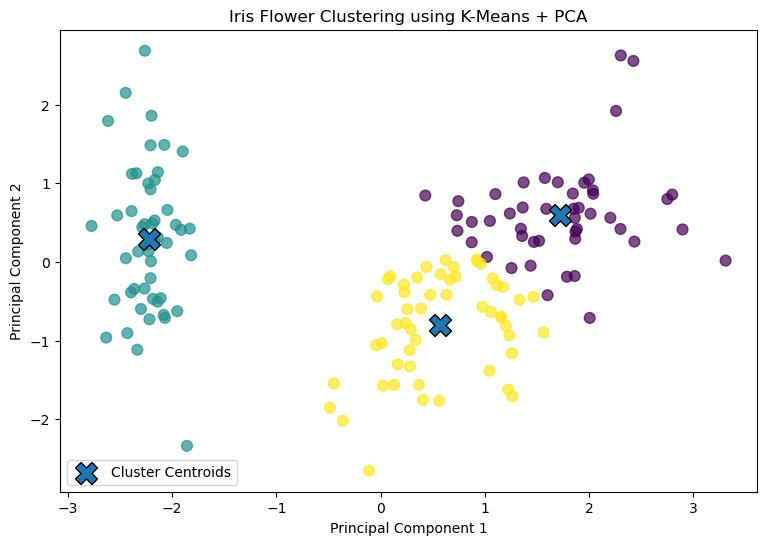

In [28]:
centers_pca = pca.transform(
    kmeans.cluster_centers_
)

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=predicted_clusters,
    cmap="viridis",
    s=60,
    alpha=0.7
)

plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    marker="X",
    s=250,
    edgecolor="black",
    label="Cluster Centroids"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "Iris Flower Clustering using K-Means + PCA"
)

plt.legend()

plt.show()

# Final Results

In [29]:
print("=" * 50)
print("IRIS FLOWER CLUSTERING PROJECT")
print("=" * 50)

print("\nNumber of Clusters:", 3)

print("\nCluster Distribution:")
print(cluster_counts)

print("\nPCA Explained Variance:")
print(pca.explained_variance_ratio_)

print(
    "\nTotal PCA Explained Variance:",
    pca.explained_variance_ratio_.sum()
)

print(
    "\nAdjusted Rand Index:",
    ari_score
)

IRIS FLOWER CLUSTERING PROJECT

Number of Clusters: 3

Cluster Distribution:
0    47
1    50
2    53
Name: count, dtype: int64

PCA Explained Variance:
[0.72962445 0.22850762]

Total PCA Explained Variance: 0.9581320720000165

Adjusted Rand Index: 0.6201351808870379
